In [1]:
import os

os.environ["TF_ENABLE_ONEDNN_OPTS"]="0"

import numpy as np
import tensorflow as tf
from tabulate import tabulate
from tensorflow.python.client import device_lib
from tqdm import tqdm
import time

from tensorflow.keras import mixed_precision


# tf.keras.mixed_precision.set_global_policy('mixed_float16')

tf.config.optimizer.set_jit(False)


2025-10-25 18:20:53.904518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761396653.916384 2276032 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761396653.920143 2276032 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761396653.929690 2276032 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761396653.929715 2276032 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761396653.929716 2276032 computation_placer.cc:177] computation placer alr

In [2]:

def print_gpu_details():
    """Prints all available GPUs in a formatted table with key details"""
    # Get list of all devices
    devices = device_lib.list_local_devices()
    gpu_details = []
    
    for device in devices:
        if device.device_type == 'GPU':
            # Extract details from the device description string
            desc = device.physical_device_desc
            details = {
                'Device ID': device.name.split(':')[-1],
                'Name': desc.split('name: ')[1].split(',')[0] if 'name: ' in desc else 'Unknown',
                'Memory (GB)': f"{device.memory_limit / (1024**3):.2f}",
                'PCI Bus ID': desc.split('pci bus id: ')[1].split(',')[0] if 'pci bus id: ' in desc else 'Unknown',
                'GFX Version': os.environ.get('HSA_OVERRIDE_GFX_VERSION', 'Native')
            }
            gpu_details.append(details)
    
    # Print table if GPUs found
    if gpu_details:
        print("\n" + "="*85)
        print("ACTIVE GPU CONFIGURATION".center(85))
        print("="*85)
        print(tabulate(gpu_details, headers="keys", tablefmt="grid"))
        print("="*85+ "\n")
    else:
        print("No GPU devices found!")


def configure_gpu(vram_limit):
    """Configure GPU settings with optional GFX override"""
    
    # Verify GPU availability
    gpus = tf.config.list_physical_devices('GPU')
    
    if gpus:
        try:
            # Limit VRAM on the specified GPU
            
            for gid in range(len(gpus)):
                
                tf.config.experimental.set_virtual_device_configuration(
                    gpus[gid],
                    [tf.config.experimental.VirtualDeviceConfiguration(
                        memory_limit=vram_limit[gid] * 1024)]  # Convert GB to MB
                )
                print(f"GPU {gid} VRAM limited to {vram_limit[gid]}GB")
                
        except RuntimeError as e:
            print(f"Error setting VRAM limit: {e}")
    
    if not gpus:
        raise RuntimeError(f"No GPU found")
    
    for gid in range(len(gpus)):
        print(f"Configured GPU {gid}: {tf.config.experimental.get_device_details(gpus[gid])}") 
        
        with tf.device('/GPU:'+str(gid)):  # Force GPU usage
            x = tf.ones((1, 1))    # Smallest possible tensor
            y = x + 1              # Simple operation
            y.numpy()              # Force execution

In [3]:
VRAM = [3.55]

configure_gpu(VRAM)

print_gpu_details()

GPU 0 VRAM limited to 3.55GB
Configured GPU 0: {'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU'}

                               ACTIVE GPU CONFIGURATION                              
+-------------+------------------------------------+---------------+--------------+---------------+
|   Device ID | Name                               |   Memory (GB) | PCI Bus ID   | GFX Version   |
+=============+====================================+===============+==============+===============+
|           0 | NVIDIA GeForce RTX 3050 Laptop GPU |          3.55 | 0000:01:00.0 | Native        |
+-------------+------------------------------------+---------------+--------------+---------------+



I0000 00:00:1761396657.495753 2276032 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3635 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1761396657.552902 2276032 gpu_device.cc:2019] Created device /device:GPU:0 with 3635 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint # type: ignore
from pprint import pprint
# -------------------------
# Constants
# -------------------------

dataset_detail=np.load("/mnt/Extra/Project_Storage/stereo_ML_dataset/org/"+"feat_detail.npy", allow_pickle=True)
dataset_detail=dataset_detail.tolist()

patch_shape = (int(dataset_detail[0]),int(dataset_detail[1]))

sample_size = min(int(dataset_detail[2]),int(2**17+1))
# target=1000

Dmax = int(dataset_detail[3])
Dmin = int(dataset_detail[4])

resize_fraction = dataset_detail[5]
resize_factor = 1/resize_fraction

feature_dimension =int (dataset_detail[6])

disparity_skip = int(dataset_detail[7])

eff_Dmax = (Dmax-Dmin)//(disparity_skip+1)




In [5]:


org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/"
dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/feat_data/"
# dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/train/sampled/"

# -------------------------
# Load memmap datasets
# -------------------------
left_patch_memmap = dataset_org_path + "left_patch.dat"
left_feat_memmap = dataset_org_path + "left_feat.dat"
right_strip_memmap = dataset_org_path + "right_strip.dat"
right_feat_memmap = dataset_org_path + "right_feat.dat"
patch_disparity_memmap = dataset_org_path + "patch_disp.dat"


model_location = org_path+"model/feat/"

patch_feat =np.memmap(left_feat_memmap, dtype=np.float32, mode='r', shape=(sample_size, feature_dimension))
strip_feat =np.memmap(right_feat_memmap, dtype=np.float32, mode='r', shape=(sample_size,  eff_Dmax, feature_dimension))

median_disp   = np.memmap(patch_disparity_memmap, dtype=np.int16, mode='r', shape=(sample_size,))

default_mask = np.ones((sample_size, eff_Dmax), dtype=np.bool_)

# patch_feat =np.zeros( dtype=np.float32,shape=(sample_size, feature_dimension))
# strip_feat =np.zeros( dtype=np.float32, shape=(sample_size, eff_Dmax, feature_dimension))
# median_disp = np.zeros( dtype=np.int32,  shape=(sample_size,))

# patch_feat[:] = patch_feat_mem[:]
# strip_feat[:] = strip_feat_mem[:]
# median_disp[:] = (median_disp_mem[:]).astype(np.int32)

# total_bytes = (patch_feat.nbytes + strip_feat.nbytes + default_mask.nbytes + median_disp.nbytes)
# print(f"Total dataset size: {total_bytes / (1024**3):.2f} GB")


In [6]:
# def data_printer(array):
#     print("Min : ",np.min(array))
#     print("Mean : ",np.mean(array))
#     print("Median : ",np.median(array))
#     print("Max : ",np.max(array))
#     print('\n')
    
# data_printer(patch_feat)
# data_printer(strip_feat)
# data_printer(median_disp)
# data_printer(default_mask)


In [7]:
# -------------------------
# Imports
# -------------------------
import tensorflow as tf
from tensorflow.keras import layers, models
import os


# -------------------------
# Checkpoint callback 
# -------------------------
class Checkpoint(tf.keras.callbacks.Callback):
    def __init__(self, model_location, save_every=4):
        super().__init__()
        self.model_location = model_location
        self.save_every = save_every
        os.makedirs(model_location, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_every == 0:
            filename = os.path.join(self.model_location, f"model_epoch_{epoch+1:02d}.keras")
            self.model.save(filename)
            print(f"\n Saved model checkpoint: {filename}\n")


# -------------------------
# GPU Memory Logger
# -------------------------
class GPUMemoryLogger(tf.keras.callbacks.Callback):
    def __init__(self, device_index=0):
        super().__init__()
        self.device_index = device_index

    def on_train_batch_end(self, batch, logs=None):
        try:
            mem_info = tf.config.experimental.get_memory_info(f'GPU:{self.device_index}')
            used = mem_info['current'] / (1024 ** 2)
            peak = mem_info['peak'] / (1024 ** 2)
            print(f"Batch {batch}: GPU{self.device_index} memory used = {used:.1f} MB | peak = {peak:.1f} MB")
        except Exception as e:
            print(f"Could not fetch GPU info: {e}")
            
import subprocess
import re
import tensorflow as tf

# -------------------------
# GPU Utilization Logger
# -------------------------
class GPUUtilizationLogger(tf.keras.callbacks.Callback):
    def __init__(self, device_index=0):
        super().__init__()
        self.device_index = device_index

    def on_train_batch_end(self, batch, logs=None):
        try:
            result = subprocess.run(
                ['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,nounits,noheader', '-i', str(self.device_index)],
                stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
            )
            if result.returncode == 0:
                usage = int(result.stdout.strip())
                print(f"Batch {batch}: GPU{self.device_index} utilization = {usage}%")
            else:
                print(f"Batch {batch}: Could not fetch GPU utilization: {result.stderr.strip()}")
        except Exception as e:
            print(f"Could not fetch GPU utilization: {e}")


checkpoint_cb = Checkpoint(model_location, save_every=5)
gpu_logger = GPUMemoryLogger()
gpu_util = GPUUtilizationLogger()


In [8]:

import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

import numpy as np

def compute_gaussian_targets(disparities, D, sigma=1.0):
    disparities = np.asarray(disparities)
    N = disparities.shape[0]
    d_range = np.arange(D)
    
    # Vectorized Gaussian computation
    y_gauss = np.exp(-0.5 * ((d_range[None, :] - disparities[:, None]) / sigma) ** 2)
    
    # Normalize so that each row sums to 1
    y_gauss /= y_gauss.sum(axis=1, keepdims=True)
    
    return y_gauss.astype(np.float32)



class StereoBatchGenerator(Sequence):
    def __init__(self,left_feat, right_feat, disp_gauss, disp_mask, sigma=1.0,
                disp_skip=0, batch_size=32, indices=None, shuffle=True, **kwargs):
        
        super().__init__(**kwargs)
        self.feat_l = left_feat
        self.feat_r = right_feat
        self.shuffle = shuffle
        self.batch_size = batch_size
        self.disp_gauss = disp_gauss
        self.mask = disp_mask
        self.disp_skip = disp_skip
        self.sigma = sigma

        # Indices for shuffling
        if indices is None:
            self.indices = np.arange(len(self.left_feat))
        else:
            self.indices = np.array(indices)

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        if self.disp_skip > 0:
            step = self.disp_skip + 1     # (B, Dmax/(skip+1), H, W, 1)
            strip_feat = self.feat_r[batch_idx, ::step, :]
            strip_mask = self.mask[batch_idx, ::step]
        else:
            strip_feat = self.feat_r[batch_idx]
            strip_mask = self.mask[batch_idx]

        patch_feat = self.feat_l[batch_idx]

        disp_range = self.disp_gauss[batch_idx] 

        return (
            (patch_feat, strip_feat, strip_mask),
            disp_range
        )

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


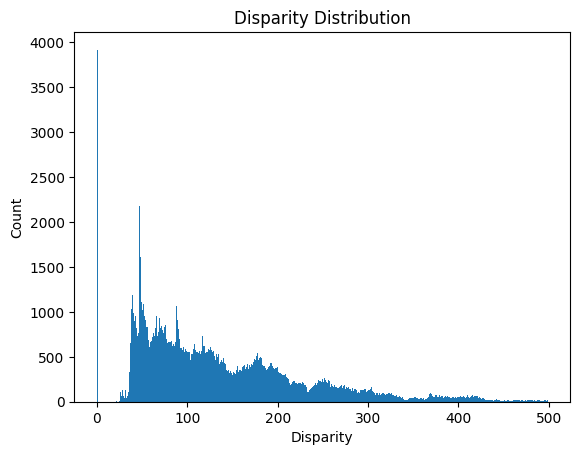

In [9]:

import matplotlib.pyplot as plt
plt.hist(median_disp, bins=np.arange(median_disp.min(), median_disp.max()+1))
plt.title("Disparity Distribution")
plt.xlabel("Disparity")
plt.ylabel("Count")
plt.show()




In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

# =========================================================
# Layer: Dynamic Feature Weighting + Similarity (with normalization)
# =========================================================
class FeatureWeightedSimilarity(layers.Layer):
    """
    Computes feature-wise weighted similarity.
    The weights are dynamically generated from the left embedding.
    """
    def __init__(self, emb_dim=None, **kwargs):
        super().__init__(**kwargs)
        self.emb_dim = emb_dim
        self.weight_dense = None  # initialized in build

    def build(self, input_shape):
        emb_dim = input_shape[0][-1] if self.emb_dim is None else self.emb_dim
        self.weight_dense = layers.Dense(emb_dim, activation='sigmoid')
        super().build(input_shape)

    def call(self, inputs):
        left_emb, right_emb = inputs  # (B, emb), (B, D, emb)
        
        # Compute dynamic weights (attention vector) from left_emb
        weights = tf.nn.softmax(self.weight_dense(left_emb), axis=-1)  # (B, emb)
        weights_exp = tf.expand_dims(weights, axis=1)                  # (B, 1, emb)
        
        # Apply feature-wise weighting
        weighted_left = left_emb * tf.squeeze(weights_exp, axis=1)
        weighted_right = right_emb * weights_exp

        # Normalize embeddings to prevent large dot product scores
        weighted_left = tf.nn.l2_normalize(weighted_left, axis=-1)
        weighted_right = tf.nn.l2_normalize(weighted_right, axis=-1)

        # Compute similarity (dot product)
        left_exp = tf.expand_dims(weighted_left, 1)  # (B, 1, emb)
        scores = tf.reduce_sum(left_exp * weighted_right, axis=-1)  # (B, D)
        return scores  # raw logits


# =========================================================
# Masked logits adjustment (optional)
# =========================================================
class MaskedLogits(layers.Layer):
    """
    Apply mask to logits: invalid positions get large negative value
    so that after softmax they have ~0 probability.
    """
    def call(self, inputs):
        logits, mask = inputs  # (B, D), (B, D)
        mask = tf.cast(mask, tf.bool)
        masked_logits = tf.where(mask, logits, tf.constant(-1e9, dtype=logits.dtype))
        return masked_logits



# =========================================================
# Model Builder
# =========================================================
def build_model(max_d, feat_dim, emb_list, dropout_rate=0.2):
    # Inputs
    left_input = layers.Input(shape=(feat_dim,), name='left_feat')
    right_input = layers.Input(shape=(max_d, feat_dim), name='right_feat')
    mask_input = layers.Input(shape=(max_d,), dtype=tf.bool, name='mask')

    # Shared encoder
    def make_encoder():
        inp = layers.Input(shape=(feat_dim,))
        x = layers.LayerNormalization()(inp)
        for emb in emb_list:
            x = layers.Dense(emb, activation='relu')(x)
            x = layers.Dropout(dropout_rate)(x)
        return Model(inp, x)

    shared_encoder = make_encoder()

    # Encode both sides
    left_emb = shared_encoder(left_input)                             # (B, emb)
    right_emb = layers.TimeDistributed(shared_encoder)(right_input)   # (B, D, emb)

    # Similarity (logits) layer
    scores = FeatureWeightedSimilarity()([left_emb, right_emb])       # (B, D)
    
    masked_scores = MaskedLogits()([scores, mask_input])

    # Model outputs raw logits (softmax applied only at inference if needed)
    model = Model(inputs=[left_input, right_input, mask_input],
                outputs=masked_scores, name="Stereo_Feature_Matching")
    
    return model

# =========================================================
# Metric: off-by-k accuracy for Gaussian targets
# =========================================================
def off_by_k_gauss(k):
    def metric(y_true, y_pred):
        # predicted disparity
        pred_disp = tf.reduce_sum(tf.range(y_pred.shape[-1], dtype=tf.float32)[None, :] * tf.nn.softmax(y_pred, axis=-1), axis=-1)
        # true disparity (can be fractional)
        true_disp = tf.reduce_sum(tf.range(y_true.shape[-1], dtype=tf.float32)[None, :] * y_true, axis=-1)
        off_k = tf.abs(pred_disp - true_disp) <= k
        return tf.reduce_mean(tf.cast(off_k, tf.float32))
    return metric



# =========================================================
# Training function (generator already produces Gaussian)
# =========================================================
def train_model(model, train_gen, val_gen, k=2, lr=1e-3, epochs=10):
    
    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=lr,
        first_decay_steps=2000,
        t_mul=2.0,
        m_mul=1.0,
        alpha=0.0,
    )

    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        mode='min',
        min_delta=1e-4
    )
    
    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss=loss_fn,
        metrics=[off_by_k_gauss(k)]
    )
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[checkpoint_cb,early_stop],
        steps_per_epoch=len(train_gen),
        validation_steps=len(val_gen),
    )

    return history


In [11]:

BATCH_SIZE = 32
EPOCHS = 500
DISP_SKIP = 3
# -----------------------------------------------------------
# Usage
# -----------------------------------------------------------

from sklearn.model_selection import train_test_split
from tensorflow.keras import optimizers, callbacks

# -----------------------------------------------------------
# Build generators for image + precomputed features
# -----------------------------------------------------------
all_indices = np.arange(len(patch_feat))
idx_train, idx_val = train_test_split(all_indices, test_size=0.1, random_state=42)


# from sklearn.model_selection import train_test_split

# Xl_train, Xl_val, Xr_train, Xr_val, Xm_train, Xm_val, y_train, y_val = train_test_split(
#     patch_feat, strip_feat, default_mask, median_disp, test_size=0.1, random_state=42
# )

# train_gen= ((Xl_train, Xr_train, Xm_train),y_train)
# val_gen= ((Xl_val, Xr_val, Xm_val),y_val)


disp_gauss = compute_gaussian_targets((median_disp.astype(np.float32))/(DISP_SKIP+1), (eff_Dmax//(DISP_SKIP+1)), sigma=0.1)
print(disp_gauss.shape)  # (sample_size, eff_Dmax)

train_gen = StereoBatchGenerator(
    left_feat=patch_feat,
    right_feat=strip_feat,
    disp_mask = default_mask,
    disp_gauss=disp_gauss,
    batch_size=BATCH_SIZE,
    indices=idx_train,
    disp_skip=DISP_SKIP,
    shuffle=True
)

val_gen = StereoBatchGenerator(
    left_feat=patch_feat,
    right_feat=strip_feat,
    disp_mask = default_mask,
    disp_gauss=disp_gauss,
    batch_size=BATCH_SIZE,
    indices=idx_val,
    disp_skip=DISP_SKIP,
    shuffle=True
)

embedding_dimension = [8, 16, 32, 64, 128, 256][2:5]

model = build_model(max_d=(eff_Dmax//(DISP_SKIP+1)), feat_dim=feature_dimension, emb_list = embedding_dimension, dropout_rate=0.08)

model.summary()

(131073, 125)


Model: "Stereo_Feature_Matching"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_feat           │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_feat          │ (None, 125, 7)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 128)       │     10,702 │ left_feat[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 125, 128)  │     10,702 │ right_feat[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_weighted_s… │ (None, 125)       │     16,512 │ functional[0][0], │
│ (FeatureWeightedSi… │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (InputLayer)   │ (None, 125)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_logits       │ (None, 125)       │          0 │ feature_weighted… │
│ (MaskedLogits)      │                   │            │ mask[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,214 (106.30 KB)

 Trainable params: 27,214 (106.30 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# from sklearn.utils.class_weight import compute_class_weight

# classes = np.arange(eff_Dmax)
# existing = np.unique(median_disp)
# weights_existing = compute_class_weight('balanced', classes=existing, y=median_disp)
# weights = {int(c): float(w) for c, w in zip(existing, weights_existing)}

# # Fill missing with neutral weight
# for c in classes:
#     weights.setdefault(int(c), 0.0)
    
# weights_list = np.array([weights[c] for c in classes])
# weights_normalized = weights_list / weights_list.mean()
# weights = {c: w for c, w in zip(classes, weights_normalized)}


# # print("Unique labels:", classes)
# # print("Weights:", class_weights)

In [ ]:


k_actual = 4

k_off_value = int(np.ceil((k_actual/(disparity_skip+1))/(DISP_SKIP+1)))
print("K Off Metric :",k_off_value,"\n\n")

history = train_model(model, train_gen, val_gen, k=k_off_value, epochs=EPOCHS)

K Off Metric : 1 


Epoch 1/500


I0000 00:00:1761396676.234441 2276157 service.cc:152] XLA service 0x730de4002d80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761396676.234460 2276157 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-25 18:21:17.255790: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1761396682.778574 2276157 cuda_dnn.cc:529] Loaded cuDNN version 90701


   1/3687 ━━━━━━━━━━━━━━━━━━━━ 164:37:39 161s/step - loss: 4.7854 - metric: 0.0625

I0000 00:00:1761396819.625800 2276157 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3686/3687 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 4.6496 - metric: 0.0129

2025-10-25 18:26:41.379478: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5114', 12 bytes spill stores, 12 bytes spill loads

2025-10-25 18:26:48.055138: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5114', 12 bytes spill stores, 12 bytes spill loads



3687/3687 ━━━━━━━━━━━━━━━━━━━━ 353s 52ms/step - loss: 4.6246 - metric: 0.0134 - val_loss: 4.5645 - val_metric: 0.0146
Epoch 2/500
3687/3687 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 4.6025 - metric: 0.0129 - val_loss: 4.5593 - val_metric: 0.0159
Epoch 3/500
3687/3687 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 4.5948 - metric: 0.0129 - val_loss: 4.5510 - val_metric: 0.0146
Epoch 4/500
3687/3687 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 4.5897 - metric: 0.0131 - val_loss: 4.5501 - val_metric: 0.0152
Epoch 5/500
3685/3687 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.5905 - metric: 0.0134
 Saved model checkpoint: /mnt/Extra/Project_Storage/stereo_ML_dataset/model/feat/model_epoch_05.keras

3687/3687 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 4.5901 - metric: 0.0134 - val_loss: 4.5468 - val_metric: 0.0155
Epoch 6/500
3687/3687 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 4.5842 - metric: 0.0129 - val_loss: 4.5441 - val_metric: 0.0141
Epoch 7/500
3687/3687 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step -

In [ ]:
# mask = np.ones((num_samples, Dmax), dtype=bool)  # all True during training
# probabilities = model.predict([left_patch_feat, right_patch_feat, mask])
# pred_disp = np.argmax(probabilities, axis=-1)


In [ ]:

import numpy as np

# Save
np.save(model_location+"history.npy", history.history)

model.save(model_location+"best_model.keras")
